In [3]:
import pandas as pd
import warnings
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
import os
import json

In [4]:
city = 'Bangalore'

df = pd.read_json(rf'../web scraping/{city}/car_dataset_{city.lower()}.json', lines=True)
df.head()

,url,car_name,Price,Registration Year,Insurance,Fuel Type,Seats,Kms Driven,RTO,Ownership,...,Charging Time,Fast Charging,Range - Tested,3rd Gear (30-80kmph),4th Gear (40-100kmph),Petrol Mileage WLTP,CNG Mileage ARAI,CNG Fuel Tank Capacity,Petrol Fuel Tank Capacity (Litres),Petrol Overall Mileage
0,https://www.cardekho.com/used-car-details/used...,Skoda Superb,₹26.65 Lakh,Jan 2021,Comprehensive,Petrol,5 Seats,"54,626 Kms",Bangalore,First Owner,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,https://www.cardekho.com/buy-used-car-details/...,Kia Seltos,₹10.37 Lakh,Jan 2021,Comprehensive,Petrol,5 Seats,"50,756 Kms",Bangalore,Second Owner,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,https://www.cardekho.com/buy-used-car-details/...,Maruti Suzuki Grand Vitara,₹12.82 Lakh,Dec 2022,Third Party,Petrol,5 Seats,"18,513 Kms",Bangalore,First Owner,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,https://www.cardekho.com/buy-used-car-details/...,Maruti Suzuki Grand Vitara,₹11.04 Lakh,May 2023,Comprehensive,Petrol,5 Seats,"38,543 Kms",Bangalore,First Owner,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,https://www.cardekho.com/used-car-details/used...,Tata Safari,₹23.50 Lakh,2023,-,Diesel,7 Seats,"30,000 Kms",Bangalore,First Owner,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
PROCESSED_FILES_LOG = 'processed_files.txt'

def get_processed_files():
    if os.path.exists(PROCESSED_FILES_LOG):
        with open(PROCESSED_FILES_LOG, 'r') as f:
            return f.read().splitlines()
    return []

def mark_file_as_processed(json_filename):
    processed = get_processed_files()
    if json_filename not in processed:
        with open(PROCESSED_FILES_LOG, 'a') as f:
            f.write(json_filename + '\n')

In [6]:
# ─────────────────────────────────────────
json_file = f'car_dataset_{city.lower()}.json'

if json_file in get_processed_files():
    print(f"⚠️ '{json_file}' already processed — skipping!")
    df = pd.read_csv('dataset.csv')  
    print(f"Loaded existing dataset with {len(df)} rows")
    
else:  
    req_col = []
    with open('features.txt', 'r') as f:
        features = f.read().split('\n')
    for i in features:
        if i in df.columns:
            req_col.append(i)
    # ✅ removed req_col.append('city')
    df = df[req_col]

    before = len(df)
    df = df.drop_duplicates()
    print(f"Duplicates removed from new data: {before - len(df)} rows")

    if os.path.exists('dataset.csv') and os.path.getsize('dataset.csv') > 0:
        existing_df = pd.read_csv('dataset.csv')
        combined_df = pd.concat([existing_df, df], ignore_index=True)

        before = len(combined_df)
        combined_df = combined_df.drop_duplicates()
        print(f"Duplicates removed from combined data: {before - len(combined_df)} rows")

        combined_df.to_csv('dataset.csv', index=False)
        print(f"Appended {len(df)} rows. Total rows: {len(combined_df)}")
    else:
        df.to_csv('dataset.csv', index=False)
        print(f"Created new dataset.csv with {len(df)} rows")

    mark_file_as_processed(json_file)
    print(f"✅ '{json_file}' marked as processed!")

⚠️ 'car_dataset_bangalore.json' already processed — skipping!
Loaded existing dataset with 1010 rows


In [7]:
df = pd.read_csv('dataset.csv')

In [8]:
df.columns

Index(['Engine', 'No. of Cylinders', 'Valves Per Cylinder',
       'Valve Configuration', 'Fuel Supply System', 'Fuel Type', 'Engine Type',
       'Emission Norm Compliance', 'Kerb Weight', 'Drive Type', 'Transmission',
       'Power'],
      dtype='object')

In [9]:
# Print percentage missing in each feature
for col in df.columns:
    print(f'{col}: {df[col].isnull().sum() / len(df) * 100}')
    

Engine: 0.891089108910891
No. of Cylinders: 0.891089108910891
Valves Per Cylinder: 0.891089108910891
Valve Configuration: 39.504950495049506
Fuel Supply System: 29.9009900990099
Fuel Type: 0.09900990099009901
Engine Type: 3.4653465346534658
Emission Norm Compliance: 8.01980198019802
Kerb Weight: 10.495049504950495
Drive Type: 15.049504950495049
Transmission: 0.09900990099009901
Power: 2.7722772277227725


In [10]:
def one_hot_encode_with_info(df, column_name, prefix=None):
    
    if prefix is None:
        prefix = column_name

    # get categories
    categories = sorted(df[column_name].dropna().unique())

    print(f"\nFeature: {column_name}")
    print("All Categories:", categories)

    dropped_category = categories[0]
    print("Dropped Category:", dropped_category)

    # create dummies
    dummies = pd.get_dummies(
        df[column_name],
        prefix=prefix,
        drop_first=True
    )

    # add to dataframe
    df = pd.concat([df, dummies], axis=1)

    # drop original column
    df.drop(columns=[column_name], inplace=True)

    return df, dropped_category

1. Engine

In [11]:
df["Engine"] = (
    df["Engine"]
    .astype(str)
    .str.replace(r"[^\d.]", "", regex=True)    
)

df["Engine"] = pd.to_numeric(df["Engine"], errors="coerce")
df['Engine'].fillna(df['Engine'].median(), inplace=True)

2. No. of Cylinders

In [12]:
df['No. of Cylinders'].fillna(df['No. of Cylinders'].mode()[0], inplace=True)

3. Valves Per Cylinder

In [13]:
df['Valves Per Cylinder'].fillna(df['Valves Per Cylinder'].mode()[0], inplace=True)

4. Fuel Supply System

In [14]:
df['Fuel Supply System'].fillna(df['Fuel Supply System'].mode()[0], inplace=True)

In [15]:
def clean_fuel_supply(x):
    if pd.isna(x):
        return None

    x = str(x).strip().lower()

    if "mpfi" in x or "multi point" in x or "mpi" in x:
        return "MPFI"

    elif "crdi" in x or "common rail" in x or "tdci" in x or "ddis" in x or "cdi" in x:
        return "CRDI"

    elif "gdi" in x or "direct injection" in x:
        return "GDI"

    elif "efi" in x or "electronic fuel injection" in x or "electronic injection" in x:
        return "EFI"

    else:
        return "Other"


df["Fuel Supply System"] = df["Fuel Supply System"].apply(clean_fuel_supply)

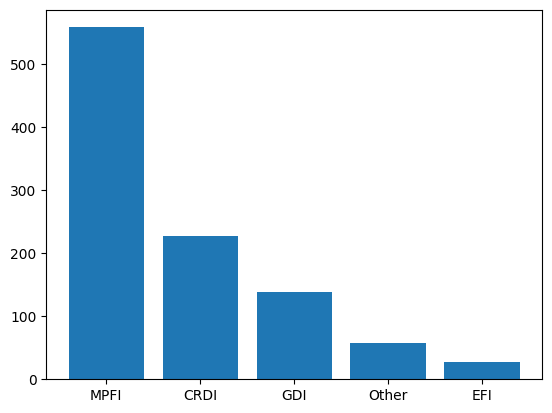

In [16]:
plt.bar(df['Fuel Supply System'].value_counts().index, df['Fuel Supply System'].value_counts().values)
plt.show()

In [17]:
df, dropped_fuel_sys = one_hot_encode_with_info(df, "Fuel Supply System", "FuelSys")


Feature: Fuel Supply System
All Categories: ['CRDI', 'EFI', 'GDI', 'MPFI', 'Other']
Dropped Category: CRDI


5. Fuel Type

In [18]:
df['Fuel Type'].fillna(df['Fuel Type'].mode()[0], inplace=True)
df['Fuel Type'].value_counts()

Fuel Type
Petrol      626
Diesel      356
CNG          21
Electric      7
Name: count, dtype: int64

In [19]:
# Drop all the row with 'Fuel Type' == 'Electric'
df = df[df['Fuel Type'] != 'Electric']

df, dropped_fuel_type = one_hot_encode_with_info(df, "Fuel Type", "Fuel")


Feature: Fuel Type
All Categories: ['CNG', 'Diesel', 'Petrol']
Dropped Category: CNG


6. 'Engine Type'

In [20]:
df['Engine Type'].fillna(df['Engine Type'].mode()[0], inplace=True)

In [21]:
def clean_engine_type(value):
    if pd.isna(value):
        return 'Unknown'
    
    value = str(value).strip()
    
    # Kappa variants
    if 'Kappa' in value or 'kappa' in value:
        return 'Kappa'
    
    # K-Series variants
    if any(x in value for x in ['K10B', 'K10C', 'K12M', 'K12N', 'K14B', 'K15B', 'K15C', 'K Series', 'K series', 'k-series', 'Advanced K']):
        return 'K Series'
    
    # i-VTEC variants (Honda Petrol)
    if any(x in value for x in ['i-VTEC', 'i VTEC', 'iVTEC', '1.2L i-VTEC', '1.2 i-VTEC']):
        return 'i-VTEC'
    
    # i-DTEC variants (Honda Diesel)
    if any(x in value for x in ['i-DTEC', 'i DTEC']):
        return 'i-DTEC'
    
    # Revotron variants (Tata Petrol)
    if any(x in value for x in ['Revotron', 'REVOTRON']):
        return 'Revotron'
    
    # Revotorq variants (Tata Diesel)
    if any(x in value for x in ['Revotorq', 'REVOTORQ']):
        return 'Revotorq'
    
    # DDiS variants (Maruti Diesel)
    if any(x in value for x in ['DDiS', 'DDIS']):
        return 'DDiS'
    
    # IRDE2 variants (Bajaj)
    if 'IRDE2' in value:
        return 'IRDE2'
    
    # TSI variants (Volkswagen Petrol)
    if 'TSI' in value:
        return 'TSI'
    
    # TDI/TDCi/TDCI variants (Diesel)
    if any(x in value for x in ['TDI', 'TDCi', 'TDCI']):
        return 'TDI'
    
    # CRDi/CRDI variants (Hyundai/Kia Diesel)
    if any(x in value for x in ['CRDi', 'CRDI', 'CRDe']):
        return 'CRDi'
    
    # mHawk variants (Mahindra Diesel)
    if any(x in value for x in ['mHawk', 'mHAWk']):
        return 'mHawk'
    
    # mStallion variants (Mahindra Petrol)
    if 'mStallion' in value:
        return 'mStallion'
    
    # Kryotec variants (Tata)
    if any(x in value for x in ['Kryotec', 'KRYOJET']):
        return 'Kryotec'
    
    # SmartStream variants (Hyundai)
    if any(x in value for x in ['SmartStream', 'SMARTSTREAM', 'Smartstream']):
        return 'SmartStream'
    
    # F8D variants (Maruti)
    if 'F8D' in value:
        return 'F8D'
    
    # VVT variants
    if any(x in value for x in ['VVT', 'VTVT', 'VVTi', 'Ti-VCT']):
        return 'VVT'
    
    # TwinPower (BMW)
    if 'TwinPower' in value:
        return 'TwinPower'
    
    # D-4D variants (Toyota Diesel)
    if any(x in value for x in ['D-4D', '2KD-FTV', '2-GD FTV']):
        return 'Toyota Diesel'
    
    # Generic Petrol
    if 'Petrol' in value or 'petrol' in value:
        return 'Petrol'
    
    # Generic Diesel
    if 'Diesel' in value or 'diesel' in value:
        return 'Diesel'
    
    # In-Line
    if 'In-Line' in value or 'In Line' in value or 'Inline' in value:
        return 'In-Line'
    
    return 'Other'


# Apply
df['Engine Type'] = df['Engine Type'].apply(clean_engine_type)

In [22]:
df['Engine Type'].value_counts()

Engine Type
Petrol           159
Other            110
Diesel           102
K Series          81
VVT               62
i-VTEC            59
CRDi              57
Kappa             52
Revotron          48
TSI               48
DDiS              36
In-Line           31
SmartStream       30
mHawk             29
TDI               19
Toyota Diesel     17
Kryotec           13
i-DTEC            13
Revotorq          11
TwinPower          9
F8D                9
mStallion          6
IRDE2              2
Name: count, dtype: int64

In [23]:
df, dropped_engine_type = one_hot_encode_with_info(
    df,
    "Engine Type",
    "EngineType"
)


Feature: Engine Type
All Categories: ['CRDi', 'DDiS', 'Diesel', 'F8D', 'IRDE2', 'In-Line', 'K Series', 'Kappa', 'Kryotec', 'Other', 'Petrol', 'Revotorq', 'Revotron', 'SmartStream', 'TDI', 'TSI', 'Toyota Diesel', 'TwinPower', 'VVT', 'i-DTEC', 'i-VTEC', 'mHawk', 'mStallion']
Dropped Category: CRDi


7. 'Emission Norm Compliance'

In [24]:
df['Emission Norm Compliance'].fillna(df['Emission Norm Compliance'].mode()[0], inplace=True)
df['Emission Norm Compliance'].value_counts()

Emission Norm Compliance
BS IV                               448
BS VI                               310
BS VI 2.0                           172
BSIV                                 27
Bharat Stage IV                       9
Euro VI                               8
Bharat Stage III                      8
Euro IV                               7
Euro V                                7
BS III                                4
BS III, BS IV (For Metro Cities)      3
Name: count, dtype: int64

In [25]:
def clean_emission_norm(x):

    if pd.isna(x):
        return None

    x = str(x).strip().lower()

    if "bs vi" in x or "bsvi" in x:
        return "BS6"

    elif "bs iv" in x or "bsiv" in x or "bharat stage iv" in x:
        return "BS4"

    elif "bs iii" in x or "bharat stage iii" in x:
        return "BS3"

    elif "euro" in x:
        return "EURO"

    else:
        return "Other"


df["Emission Norm Compliance"] = df["Emission Norm Compliance"].apply(clean_emission_norm)

In [26]:
df, dropped_emission_norm = one_hot_encode_with_info(df, "Emission Norm Compliance", "EmissionNorm")


Feature: Emission Norm Compliance
All Categories: ['BS3', 'BS4', 'BS6', 'EURO']
Dropped Category: BS3


8. 'Kerb Weight'

In [27]:
df['Kerb Weight'] = df['Kerb Weight'].str.extract(r'(\d+)').astype(float)

df['Kerb Weight'].fillna(df['Kerb Weight'].median(), inplace=True)

9. 'Drive Type'

In [28]:
# Filling missing with mode
df['Drive Type'].fillna(df['Drive Type'].mode()[0], inplace=True)

In [29]:
def clean_drive_type(value):
    value = str(value).strip().upper().replace(' ', '')
    
    fwd_variants = ['FWD', '2WD', '4X2', 'FRONTWHEELDRIVE', 'TWOWHEELDRIVE', 'TWOWHHEELDRIVE', 'TWOWHHHEELDRIVE']
    rwd_variants = ['RWD', 'RWD(WITHMTT)']
    awd_variants = ['AWD', '4WD', '4X4']
    
    if value in fwd_variants:
        return 'FWD'
    elif value in rwd_variants:
        return 'RWD'
    elif value in awd_variants:
        return 'AWD'
    else:
        return 'FWD'

# Apply
df['Drive Type'] = df['Drive Type'].apply(clean_drive_type)

In [30]:
df, droped_drive_type = one_hot_encode_with_info(df, "Drive Type", "DriveType")


Feature: Drive Type
All Categories: ['AWD', 'FWD', 'RWD']
Dropped Category: AWD


10. 'Transmission'

In [31]:
transmission_map = {
    "Automatic": 1,
    "Manual": 0 
}

df['Transmission'] = df['Transmission'].map(transmission_map)

df['Transmission'].fillna(df['Transmission'].mode()[0], inplace=True)

11. Power

In [32]:
df['Power'].head()

0    187.74 bhp
1    113.43 bhp
2    101.64 bhp
3    101.64 bhp
4    167.62 bhp
Name: Power, dtype: object

In [33]:
df['Power'] = df['Power'].str.replace(' bhp', '', regex=False).astype(float)

df['Power'].fillna(df['Power'].median(), inplace=True)

11. 'Valve Configuration'

In [34]:
df['Valve Configuration'].fillna(df['Valve Configuration'].mode()[0], inplace=True)

In [35]:
def clean_valve_config(value):
    value = str(value).strip().upper()
    
    if 'DOHC' in value:
        return 'DOHC'
    elif 'SOHC' in value:
        return 'SOHC'
    else:
        return value

df['Valve Configuration'] = df['Valve Configuration'].apply(clean_valve_config)
print(df['Valve Configuration'].value_counts())

Valve Configuration
DOHC    898
SOHC    103
IDSI      2
Name: count, dtype: int64


In [36]:
df, dropped_valve_config = one_hot_encode_with_info(df, "Valve Configuration", "ValveConfig")


Feature: Valve Configuration
All Categories: ['DOHC', 'IDSI', 'SOHC']
Dropped Category: DOHC


'engine_density'

In [37]:
df['Engine Density'] = df['Engine'] / df['No. of Cylinders']

df['Engine Density'].head()

0    496.00
1    338.25
2    365.50
3    365.50
4    489.00
Name: Engine Density, dtype: float64

In [38]:
bool_cols = df.select_dtypes(include='bool').columns.tolist()
df[bool_cols] = df[bool_cols].astype(int)

In [39]:
df.columns

Index(['Engine', 'No. of Cylinders', 'Valves Per Cylinder', 'Kerb Weight',
       'Transmission', 'Power', 'FuelSys_EFI', 'FuelSys_GDI', 'FuelSys_MPFI',
       'FuelSys_Other', 'Fuel_Diesel', 'Fuel_Petrol', 'EngineType_DDiS',
       'EngineType_Diesel', 'EngineType_F8D', 'EngineType_IRDE2',
       'EngineType_In-Line', 'EngineType_K Series', 'EngineType_Kappa',
       'EngineType_Kryotec', 'EngineType_Other', 'EngineType_Petrol',
       'EngineType_Revotorq', 'EngineType_Revotron', 'EngineType_SmartStream',
       'EngineType_TDI', 'EngineType_TSI', 'EngineType_Toyota Diesel',
       'EngineType_TwinPower', 'EngineType_VVT', 'EngineType_i-DTEC',
       'EngineType_i-VTEC', 'EngineType_mHawk', 'EngineType_mStallion',
       'EmissionNorm_BS4', 'EmissionNorm_BS6', 'EmissionNorm_EURO',
       'DriveType_FWD', 'DriveType_RWD', 'ValveConfig_IDSI',
       'ValveConfig_SOHC', 'Engine Density'],
      dtype='object')

---

In [40]:
from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV, train_test_split 
from sklearn.metrics import r2_score, mean_absolute_error

In [41]:
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 6, 10],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.8, 1.0]
}

grid_search = GridSearchCV(
    XGBRegressor(random_state=42),
    param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

In [42]:
X = df.drop(columns=['Power'], axis=1)
y = df['Power']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [43]:
grid_search.fit(X_train, y_train)
best_model = grid_search.best_estimator_

In [44]:
 
best_model = grid_search.best_estimator_ 
y_pred = best_model.predict(X_test)

# 3. Quick evaluation
print(f"R2 Score: {r2_score(y_test, y_pred):.4f}")
print(f"Mean Absolute Error: {mean_absolute_error(y_test, y_pred):,.2f}")

R2 Score: 0.7520
Mean Absolute Error: 9.41


In [45]:
import os
import joblib
os.makedirs("model", exist_ok=True)
joblib.dump(best_model, "model/power_model.pkl")
print("Model saved!")

Model saved!


> In the next step we will be testing the model performance with different size of data